## Fake News Detection

### Installing the required Libraries

In [2]:
pip install pandas numpy matplotlib seaborn nltk scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### For Embeddings

In [3]:
pip install sentence-transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importing the required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Downloading Stopwords

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\haris\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Load Dataset

In [6]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

### Add Labels

In [7]:
fake['label'] = 0
true['label'] = 1

### Merge the Datasets

In [8]:
df = pd.concat([fake, true])

print(df.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  


## Exploratory Data Analysis (EDA)

### Check Dataset Shape

In [9]:
print(df.shape)

(44898, 5)


### Check Dataset Info

In [10]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.6 MB
None


### Check Missing Values

In [11]:
print(df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


### Count Plot

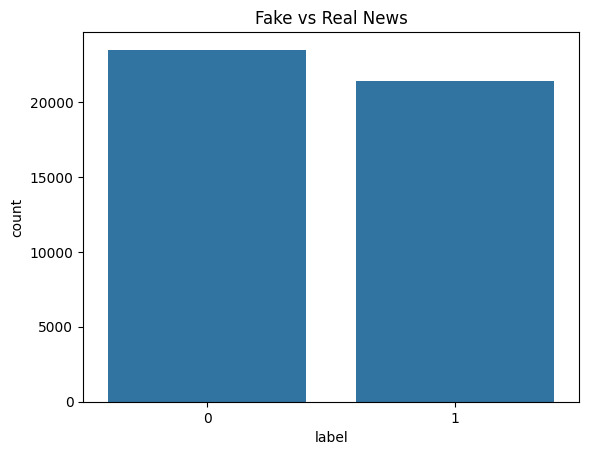

In [12]:
sns.countplot(x='label', data=df)

plt.title("Fake vs Real News")

plt.show()

## Data Cleaning

### Remove Null Values

In [13]:
df.dropna(inplace=True)

### Remove Duplicate Rows

In [14]:
df.drop_duplicates(inplace=True)

## NLP Preprocessing

### Create Preprocessing Function

In [15]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

## Apply Preprocessing

In [16]:
df['content'] = df['title'] + " " + df['text']

df['clean_text'] = df['content'].apply(preprocess)

## View Cleaned Data

In [17]:
print(df[['text', 'clean_text']].head())

                                                text  \
0  Donald Trump just couldn t wish all Americans ...   
1  House Intelligence Committee Chairman Devin Nu...   
2  On Friday, it was revealed that former Milwauk...   
3  On Christmas day, Donald Trump announced that ...   
4  Pope Francis used his annual Christmas Day mes...   

                                          clean_text  
0  donald trump sends embarrassing new year eve m...  
1  drunk bragging trump staffer started russian c...  
2  sheriff david clarke becomes internet joke thr...  
3  trump obsessed even obama name coded website i...  
4  pope francis called donald trump christmas spe...  


## Convert Text to Numbers

In [18]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

sample_texts = df['clean_text'].head(100).tolist()

X_embeddings = embedding_model.encode(sample_texts)

print(X_embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6868.04it/s]


(100, 384)


## Train Test Split

In [20]:
X = X_embeddings
y = df['label'].head(100)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
df = df.sample(frac=1, random_state=42)

## Train Model

In [24]:
print(y.value_counts())

label
0    100
Name: count, dtype: int64


In [30]:
X = embedding_model.encode(df['clean_text'].tolist())
y = df['label']

KeyboardInterrupt: 

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

## Prediction

In [ ]:
y_pred = model.predict(X_test)

## Accuracy    

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9889236965764153


### Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4670
           1       0.99      0.99      0.99      4268

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



### Confusion Matrix

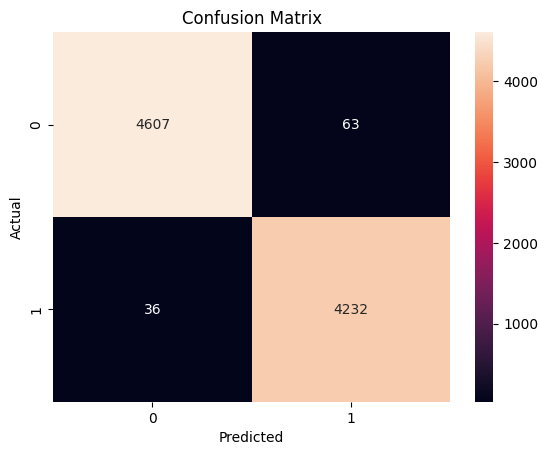

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Test Your Own News

In [ ]:
# news = ["The Reserve Bank of India increased interest rates this week"]
news = ["Aliens landed in Chennai yesterday"]
# Preprocess
news_clean = [preprocess(news[0])]

# Convert into vector
news_vector = vectorizer.transform(news_clean)

# Predict
prediction = model.predict(news_vector)

# Output
if prediction[0] == 0:
    print("Fake News")
else:
    print("Real News")

Fake News
